# 5 · Cross-dataset transfer evaluation (MANY datasets, one notebook)

Everything — the 3 heads **and** the fusion — was trained on **TriviaQA** (notebooks 1–2). Here we generate *fresh* answers for **several** datasets, score them with those already-trained heads, fuse, and report the full metric set per dataset. **Nothing is re-fit on the targets**, so every row is held out. The headline question: does **FUSED stay on top even when the best *single* detector changes** between datasets?

**Labels: the LLM-judge** (`LABEL_METHOD='llm_judge'`), paraphrase-robust. BLEURT-20@0.5 mislabels short *correct* answers (e.g. "1993" / "Gold" → halluc), inflating the hallucination rate to 40–70% and making the F1s meaningless — so we judge each answer against its gold reference instead, and drop refusals. (`LABEL_METHOD='bleurt'` reproduces the old broken labels; they save to a separate file.)

**Datasets** (config cell): `squad` + `web_questions` are unseen by the heads → real transfer; `triviaqa` is the training set, scored **held-out** via `OFFSET=3000` (past the training range 1000–2200). **nq_open was dropped** — its questions are time-sensitive/ambiguous with stale gold, so *both* BLEURT and the judge mislabel it (e.g. the correct "Eagles SB LII 2018" gets marked halluc). TruthfulQA → notebook 6.

**This is a GPU pass** (Instruct fp16; ~2 model loads + the judge per dataset). Saved to `data/<ds>_cross_eval_llm_judge.parquet` (the BLEURT files are kept separately).

In [ ]:
import os, sys
os.environ.setdefault('HF_HOME', r'D:/LLAMA CACHE/huggingface')  # reuse local LLaMA cache
sys.path.insert(0, os.path.abspath(os.path.join('..', 'hallking')))
import warnings; warnings.filterwarnings('ignore')
sys.path.insert(0, os.path.join('..','tools'))
from cross_eval import evaluate_many
# ---- CONFIG -------------------------------------------------------------------------------
DATASETS     = ['triviaqa', 'squad']  # transfer sets (web_questions + nq_open dropped: noisy/stale gold)
TRAIN        = 'triviaqa'                          # heads + fusion were trained on this
N            = 200                                 # questions per dataset
OFFSETS      = {'triviaqa': 3000}                  # keep TriviaQA held-out (training used 1000-2200)
LABEL_METHOD = 'llm_judge'                         # 'llm_judge' (paraphrase-robust) | 'bleurt' (mislabels short correct answers -> 40-70% false halluc)
# ------------------------------------------------------------------------------------------
SCORED = evaluate_many(DATASETS, train_ds=TRAIN, n=N, offsets=OFFSETS, label_method=LABEL_METHOD)
print('done:', list(SCORED.keys()))

### Per-dataset metrics (AUROC / AUPR / Accuracy / Precision / Recall / F1)

In [2]:
import os, sys
os.environ.setdefault('HF_HOME', r'D:/LLAMA CACHE/huggingface')  # reuse local LLaMA cache
sys.path.insert(0, os.path.abspath(os.path.join('..', 'hallking')))
import warnings; warnings.filterwarnings('ignore')
import metrics as M, pandas as pd, numpy as np
DETS = {'SEP':'sep_entropy', 'HalluShift':'hallushift', 'TSV':'tsv_margin', 'FUSED':'fused'}
METRICS = {}
for ds, (_, df) in SCORED.items():
    y = df['hallucination'].to_numpy()
    res = {}
    for name, col in DETS.items():
        s = df[col].to_numpy()
        m = M.detector_metrics(y, s, threshold=M.best_threshold(y, s))
        M.attach_curves(m, y, s)
        res[name] = m
    METRICS[ds] = res
    print(f'\n=== {ds}  (n={len(df)}, halluc={y.mean()*100:.1f}%) ===')
    print(M.summary_table(res).to_string())


=== triviaqa  (n=200, halluc=19.5%) ===
             AUROC    AUPR  Accuracy  Precision  Recall      F1
detector                                                       
SEP         0.5415  0.2489     0.410     0.2199  0.7949  0.3444
HalluShift  0.6756  0.2959     0.635     0.3068  0.6923  0.4252
TSV         0.6261  0.2670     0.510     0.2602  0.8205  0.3951
FUSED       0.6165  0.2628     0.495     0.2578  0.8462  0.3952

=== squad  (n=199, halluc=41.7%) ===
             AUROC    AUPR  Accuracy  Precision  Recall      F1
detector                                                       
SEP         0.6749  0.5798    0.5879     0.5036  0.8434  0.6306
HalluShift  0.6697  0.5854    0.5930     0.5070  0.8675  0.6400
TSV         0.6270  0.5627    0.5226     0.4639  0.9277  0.6185
FUSED       0.5994  0.5129    0.5075     0.4540  0.8916  0.6016

=== web_questions  (n=199, halluc=15.1%) ===
             AUROC    AUPR  Accuracy  Precision  Recall      F1
detector                                   

### ROC / PR curves + confusion matrices per dataset

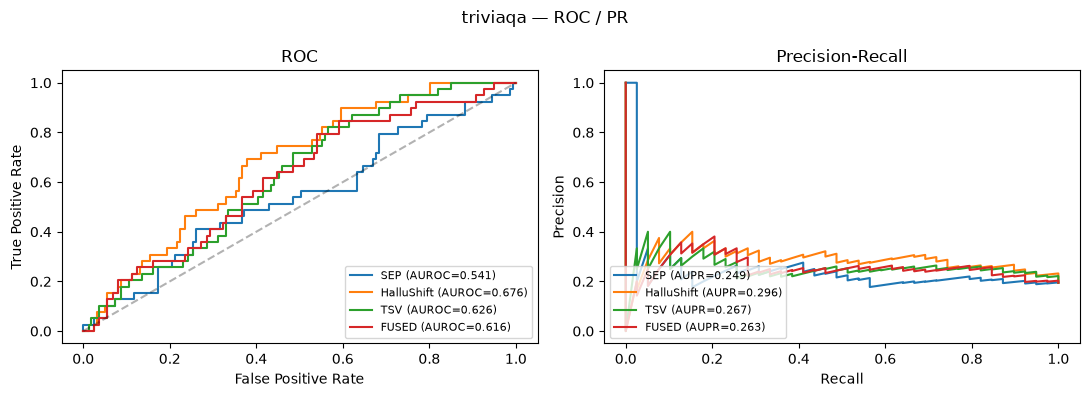

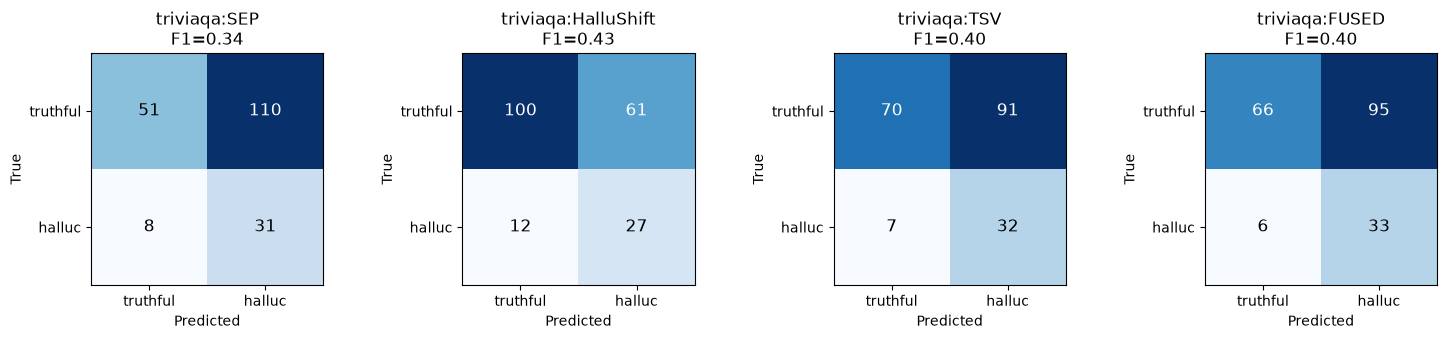

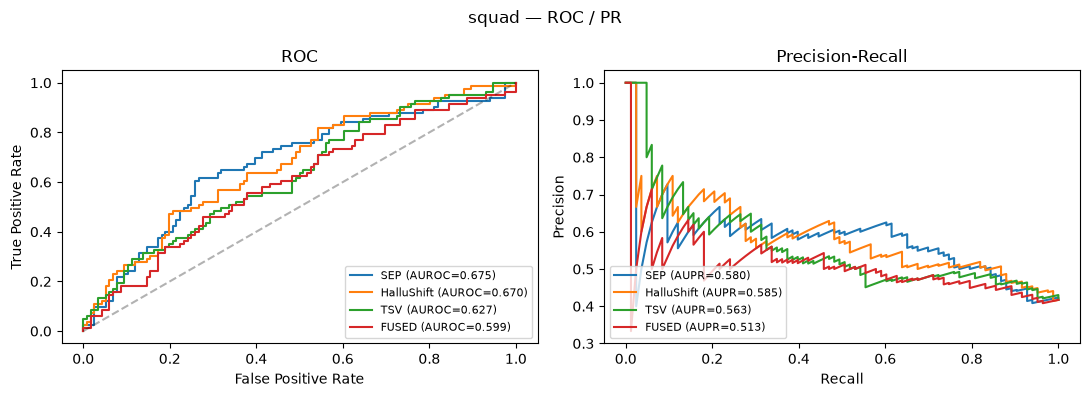

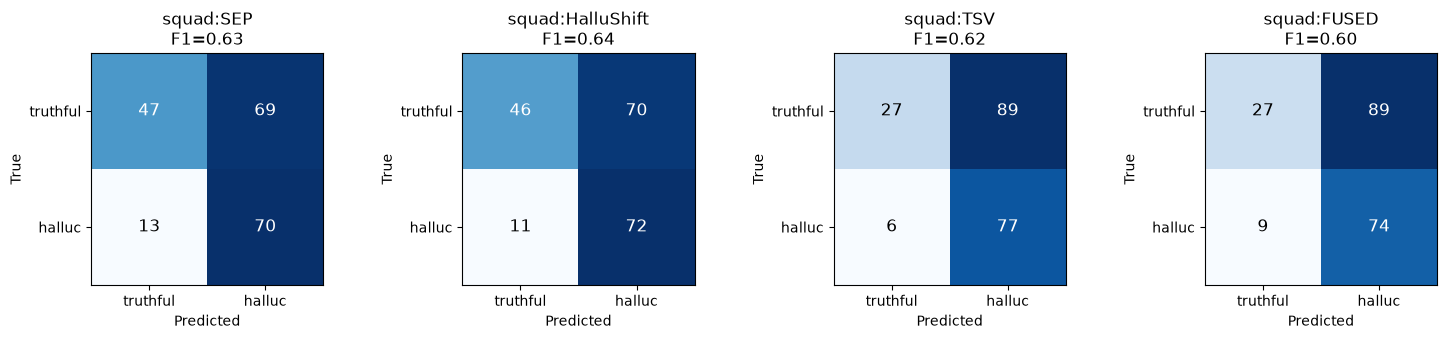

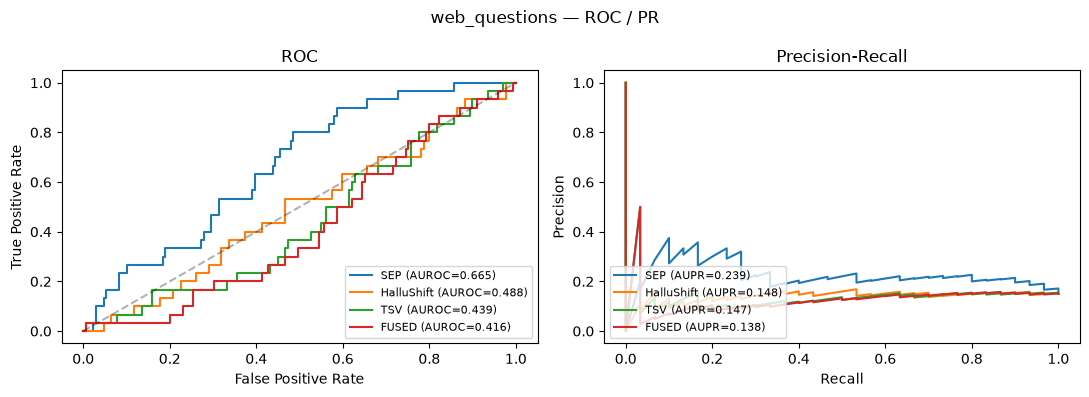

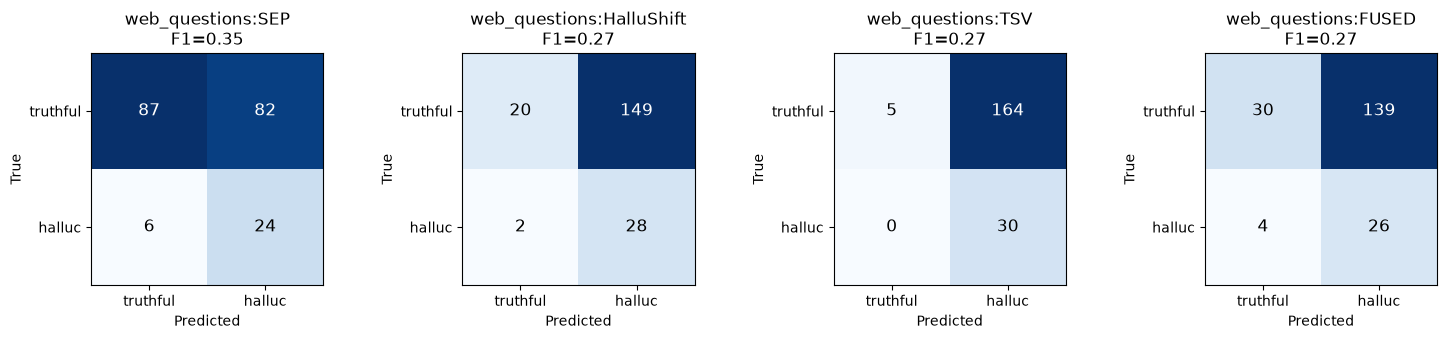

In [3]:
import matplotlib.pyplot as plt
for ds, res in METRICS.items():
    fig, ax = plt.subplots(1, 2, figsize=(11,4))
    M.plot_roc(ax[0], res); M.plot_pr(ax[1], res)
    fig.suptitle(f'{ds} — ROC / PR'); plt.tight_layout(); plt.show()
    fig, axes = plt.subplots(1, 4, figsize=(15,3.4))
    for axx,(name,m) in zip(axes, res.items()):
        M.plot_confusion(axx, m['confusion_matrix'], title=f"{ds}:{name}\nF1={m['F1']:.2f}")
    plt.tight_layout(); plt.show()

### Headline — does FUSED stay on top across datasets?

Pivot tables (rows = dataset, cols = detector). Watch the **best single detector change** between rows while **FUSED stays ≥ the best single** — that is the robustness story.

In [4]:
for metric in ['AUROC','AUPR','F1']:
    piv = pd.DataFrame({ds:{name:res[name][metric] for name in DETS}
                        for ds,res in METRICS.items()}).T.round(3)
    piv['best_single'] = piv[['SEP','HalluShift','TSV']].idxmax(axis=1)
    piv['FUSED_wins'] = piv['FUSED'] >= piv[['SEP','HalluShift','TSV']].max(axis=1)
    print(f'\n=== {metric} (rows=dataset, cols=detector) ===')
    print(piv.to_string())


=== AUROC (rows=dataset, cols=detector) ===
                 SEP  HalluShift    TSV  FUSED best_single  FUSED_wins
triviaqa       0.541       0.676  0.626  0.616  HalluShift       False
squad          0.675       0.670  0.627  0.599         SEP       False
web_questions  0.665       0.488  0.439  0.416         SEP       False

=== AUPR (rows=dataset, cols=detector) ===
                 SEP  HalluShift    TSV  FUSED best_single  FUSED_wins
triviaqa       0.249       0.296  0.267  0.263  HalluShift       False
squad          0.580       0.585  0.563  0.513  HalluShift       False
web_questions  0.239       0.148  0.147  0.138         SEP       False

=== F1 (rows=dataset, cols=detector) ===
                 SEP  HalluShift    TSV  FUSED best_single  FUSED_wins
triviaqa       0.344       0.425  0.395  0.395  HalluShift       False
squad          0.631       0.640  0.618  0.602  HalluShift       False
web_questions  0.353       0.271  0.268  0.267         SEP       False
